# 02. Analysis, Sensitivity, and Decision Support

Back half of the project: the two modelling modes compared, three sensitivity sweeps
(budget, service radius, capacity), the maps, the `recommend()` decision support tool,
and the conclusions.

Nothing here modifies the model. Every result is `solve_model()` from `src/model.py`
called with different arguments. Run `01_data_and_model.ipynb` first.

In [1]:
import os, sys, subprocess

if 'google.colab' in sys.modules:
    if not os.path.exists('/content/ev'):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pulp'], check=True)
        subprocess.run(['git', 'clone', '-q',
                        'https://github.com/rjxia993/ev-charging-siting.git',
                        '/content/ev'], check=True)
    os.chdir('/content/ev')
    subprocess.run([sys.executable, 'src/data_prep.py'], check=True)
    os.chdir('/content/ev/notebooks')

os.makedirs('../figures', exist_ok=True)
print('working directory:', os.getcwd())

working directory: /content/ev/notebooks


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pulp

import data_prep
from model import solve_model, summarize
from plotting import plot_instance, plot_solution, plot_sweep

sites, demands, D = data_prep.load_all('../data')
W = demands['weight'].values
TOTAL_DEMAND = W.sum()
print(f'loaded {len(sites)} sites, {len(demands)} demand points, '
      f'total demand {TOTAL_DEMAND:,}')

loaded 20 sites, 56 demand points, total demand 23,248


## 2.1 Compare the two modes

`min_cost` serves everyone at least cost. `max_coverage` fixes the budget and covers as
much as it can. Same data, different modelling choice.


In [4]:
def polish_assignment(res, radius=5.0, capacity_scale=1.0):
    if res['status'] != 'Optimal' or not res['built']:
        return res

    cap = sites['capacity'].values * capacity_scale
    x = {(i, j): pulp.LpVariable(f'p_{i}_{j}', lowBound=0, upBound=1)
         for i in range(len(demands)) for j in res['built'] if D[i, j] <= radius}

    p = pulp.LpProblem('polish_assignment', pulp.LpMinimize)
    p += pulp.lpSum(W[i] * D[i, j] * v for (i, j), v in x.items())
    for i in range(len(demands)):                       # no demand point over-served
        p += pulp.lpSum(v for (a, j), v in x.items() if a == i) <= 1
    for j in res['built']:                              # station capacity
        p += pulp.lpSum(W[i] * v for (i, b), v in x.items() if b == j) <= cap[j]
    p += pulp.lpSum(W[i] * v for (i, j), v in x.items()) >= res['covered'] - 1e-6

    p.solve(pulp.PULP_CBC_CMD(msg=False))
    if pulp.LpStatus[p.status] != 'Optimal':
        return res

    assign = {k: v.value() for k, v in x.items() if v.value() > 1e-6}
    covered = sum(W[i] * v for (i, j), v in assign.items())
    dist_weighted = sum(W[i] * D[i, j] * v for (i, j), v in assign.items())

    out = dict(res)
    out.update(assign=assign, covered=covered,
               coverage_pct=100 * covered / TOTAL_DEMAND,
               avg_distance=dist_weighted / covered)
    return out


def solve(budget, radius=5.0, mode='min_cost', capacity_scale=1.0):
    """solve_model(), with the distance tie-break applied in max_coverage mode."""
    r = solve_model(sites, demands, D, budget=budget, radius=radius,
                    mode=mode, capacity_scale=capacity_scale)
    if mode == 'max_coverage':
        r = polish_assignment(r, radius=radius, capacity_scale=capacity_scale)
    return r


def row(r, mode):
    return {'mode': mode,
            'status': r['status'],
            'stations built': len(r['built']),
            'construction cost': r['total_cost'],
            'coverage %': r['coverage_pct'],
            'avg drive (km)': r['avg_distance'],
            'sites': ','.join(sites.site_id.iloc[r['built']]) if r['built'] else '-'}

In [5]:
BUDGET, RADIUS = 700_000, 5.0

res_cost    = solve(BUDGET, RADIUS, mode='min_cost')
res_cov_raw = solve_model(sites, demands, D, budget=BUDGET, radius=RADIUS,
                          mode='max_coverage')            # before the tie-break
res_cov     = polish_assignment(res_cov_raw, radius=RADIUS)

summarize(res_cost, sites, label='min_cost')
print()
summarize(res_cov, sites, label='max_coverage (tie-break applied)')
print(f"\navg drive reported by max_coverage before the tie-break: "
      f"{res_cov_raw['avg_distance']:.2f} km  ->  after: {res_cov['avg_distance']:.2f} km")

compare = pd.DataFrame([row(res_cost, 'min_cost'), row(res_cov, 'max_coverage')])
compare

[min_cost] status: Optimal
  stations built   : 6 of 20
  construction cost: $643,000
  demand covered   : 23,248 (100.0%)
  average drive    : 2.59 km
  objective        : 703,188

[max_coverage (tie-break applied)] status: Optimal
  stations built   : 6 of 20
  construction cost: $643,000
  demand covered   : 23,248 (100.0%)
  average drive    : 2.59 km
  objective        : 23,248

avg drive reported by max_coverage before the tie-break: 3.29 km  ->  after: 2.59 km


,mode,status,stations built,construction cost,coverage %,avg drive (km),sites
0,min_cost,Optimal,6,643000.0,100.0,2.588944,"S04,S08,S12,S14,S16,S18"
1,max_coverage,Optimal,6,643000.0,100.0,2.588944,"S04,S08,S12,S14,S16,S18"


In [6]:
rows = []
for b in [300_000, 400_000, 500_000, 643_000, 700_000]:
    for mode in ['min_cost', 'max_coverage']:
        rows.append({'budget': b, **row(solve(b, RADIUS, mode=mode), mode)})

mode_compare = pd.DataFrame(rows)
mode_compare

,budget,mode,status,stations built,construction cost,coverage %,avg drive (km),sites
0,300000,min_cost,Infeasible,0,NaN,0.000000,NaN,-
1,300000,max_coverage,Optimal,3,276000.0,51.617343,2.258234,"S14,S16,S18"
2,400000,min_cost,Infeasible,0,NaN,0.000000,NaN,-
3,400000,max_coverage,Optimal,4,371000.0,68.823125,2.722898,"S08,S14,S16,S18"
4,500000,min_cost,Infeasible,0,NaN,0.000000,NaN,-
5,500000,max_coverage,Optimal,5,488000.0,83.835169,2.838490,"S04,S08,S14,S16,S18"
6,643000,min_cost,Optimal,6,643000.0,100.000000,2.588944,"S04,S08,S12,S14,S16,S18"
7,643000,max_coverage,Optimal,6,643000.0,100.000000,2.588944,"S04,S08,S12,S14,S16,S18"
8,700000,min_cost,Optimal,6,643000.0,100.000000,2.588944,"S04,S08,S12,S14,S16,S18"
9,700000,max_coverage,Optimal,6,643000.0,100.000000,2.588944,"S04,S08,S12,S14,S16,S18"


**Findings.** At \$700k the two modes return the *same plan*: S04, S08, S12, S14, S16,
S18, \$643,000, 100 percent covered, 2.59 km average drive. Once full coverage is
affordable the two objectives agree, and the 3.29 km that `max_coverage` reported before
the tie-break was solver degeneracy rather than a real difference.

They diverge only below \$643,000. There `min_cost` returns `Infeasible` — it is required
to serve everyone and cannot — while `max_coverage` still returns a usable plan covering
51.6 percent at \$300k and 83.8 percent at \$500k. That is the practical argument for
carrying both formulations: `min_cost` answers "what does full service cost", and
`max_coverage` is the only one of the two that answers "the budget is what it is, now
what".

## 2.2 Budget sweep

The headline chart. Sweep the budget in \$50k steps and plot coverage against it, then
locate the knee: the point past which extra money buys nothing.

In [7]:
budgets = np.arange(150_000, 1_000_001, 50_000)
rows = []
for b in budgets:
    r = solve(b, RADIUS, mode='max_coverage')
    rows.append({'budget': b,
                 'status': r['status'],
                 'n_built': len(r['built']),
                 'coverage_pct': r['coverage_pct'],
                 'spent': r['total_cost'],
                 'avg_drive': r['avg_distance'],
                 # capacity actually bought, to test what limits coverage
                 'capacity_built': sites['capacity'].iloc[r['built']].sum()})
sweep_budget = pd.DataFrame(rows)
sweep_budget.head(10)

,budget,status,n_built,coverage_pct,spent,avg_drive,capacity_built
0,150000,Optimal,1,17.205781,88000.0,2.135174,4000
1,200000,Optimal,2,34.411562,181000.0,2.267835,8000
2,250000,Optimal,2,34.411562,181000.0,2.267835,8000
3,300000,Optimal,3,51.617343,276000.0,2.258234,12000
4,350000,Optimal,4,53.337922,350000.0,2.680613,12400
5,400000,Optimal,4,68.823125,371000.0,2.722898,16000
6,450000,Optimal,5,70.543703,450000.0,2.787627,16400
7,500000,Optimal,5,83.835169,488000.0,2.838490,20000
8,550000,Optimal,5,86.028906,548000.0,2.158821,20000
9,600000,Optimal,6,87.749484,597000.0,2.854071,20400


<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_657/2346166048.py:14: SyntaxWarning: invalid escape sequence '\$'
  ax.annotate(f'knee: \${knee_exact:,.0f}\n(cheapest plan covering everyone)',


first grid budget at 100% coverage : $650,000
exact knee (cheapest full plan)    : $643,000


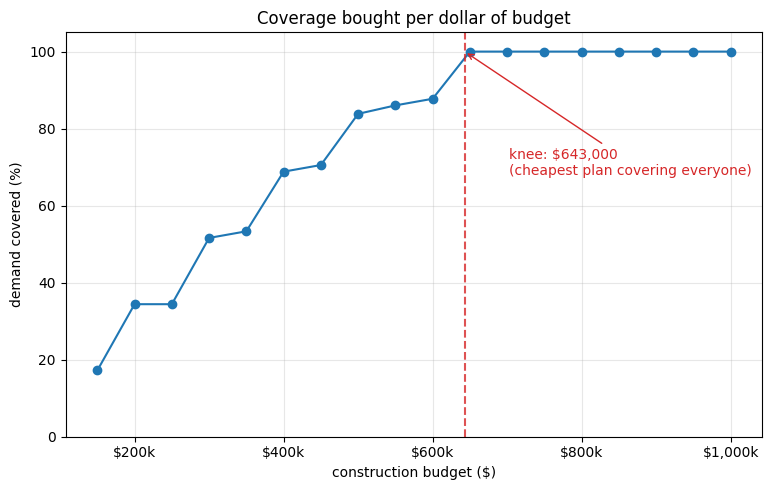

In [8]:
full = sweep_budget[sweep_budget['coverage_pct'] >= 99.99]
if full.empty:
    raise RuntimeError('no budget on the grid reaches full coverage')

knee_grid  = int(full['budget'].min())
knee_exact = solve(2_000_000, RADIUS, mode='min_cost')['total_cost']
print(f'first grid budget at 100% coverage : ${knee_grid:,}')
print(f'exact knee (cheapest full plan)    : ${knee_exact:,.0f}')

ax = plot_sweep(sweep_budget, 'budget', 'coverage_pct',
                xlabel='construction budget ($)', ylabel='demand covered (%)',
                title='Coverage bought per dollar of budget')
ax.axvline(knee_exact, color='tab:red', linestyle='--', alpha=0.8)
ax.annotate(f'knee: \${knee_exact:,.0f}\n(cheapest plan covering everyone)',
            xy=(knee_exact, 100), xytext=(knee_exact + 60_000, 68),
            arrowprops=dict(arrowstyle='->', color='tab:red'), color='tab:red')
ax.xaxis.set_major_formatter(lambda v, p: f'${v/1000:,.0f}k')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('../figures/budget_sweep.png', dpi=150)
plt.show()

In [9]:
sweep_budget['pct_per_$100k'] = (sweep_budget['coverage_pct'].diff()
                                 / (sweep_budget['budget'].diff() / 100_000)).round(2)
sweep_budget['covered'] = (sweep_budget['coverage_pct'] / 100 * TOTAL_DEMAND).round(0)
sweep_budget['binds'] = np.select(
    [np.isclose(sweep_budget['covered'], TOTAL_DEMAND, atol=1),
     np.isclose(sweep_budget['covered'], sweep_budget['capacity_built'], atol=1)],
    ['demand (all served)', 'capacity'], default='radius')

sweep_budget[['budget', 'n_built', 'spent', 'covered', 'capacity_built',
              'coverage_pct', 'pct_per_$100k', 'binds']]

,budget,n_built,spent,covered,capacity_built,coverage_pct,pct_per_$100k,binds
0,150000,1,88000.0,4000.0,4000,17.205781,NaN,capacity
1,200000,2,181000.0,8000.0,8000,34.411562,34.41,capacity
2,250000,2,181000.0,8000.0,8000,34.411562,0.00,capacity
3,300000,3,276000.0,12000.0,12000,51.617343,34.41,capacity
4,350000,4,350000.0,12400.0,12400,53.337922,3.44,capacity
5,400000,4,371000.0,16000.0,16000,68.823125,30.97,capacity
6,450000,5,450000.0,16400.0,16400,70.543703,3.44,capacity
7,500000,5,488000.0,19490.0,20000,83.835169,26.58,radius
8,550000,5,548000.0,20000.0,20000,86.028906,4.39,capacity
9,600000,6,597000.0,20400.0,20400,87.749484,3.44,capacity


**Findings.** Coverage climbs almost linearly from 17.2 percent at \$150k to 100 percent
at \$643,000, then goes completely flat: every dollar past the knee buys 0.0 additional
percentage points. \$643k is the recommendation — given \$1.0M the model spends \$951k for
exactly the same 100 percent coverage, 48 percent more money for nothing.

The `binds` column explains the shape. Below the knee, covered demand equals the summed
capacity of the stations bought at every budget except \$500k, where the 5 km radius binds
instead; above the knee all demand is served and capacity goes slack. So in the range that
matters, `max_coverage` is effectively a knapsack — buy the most capacity per dollar — and
geography barely enters. That is why \$350k builds S14, S15, S16 and S17, strung along the
west and north edge: they are the cheapest capacity on the board, even though they sit
nowhere near most of the demand. It also explains the sawtooth in the marginal column: the
\$50k steps that only swap in a 2,200-capacity fuel station move coverage by 1.7 points,
while the ones that add a 4,000-capacity garage move it by 12 to 17.

## 2.3 Service radius sweep

How far are drivers assumed to be willing to travel? The radius is a policy dial, not a
measurement, so the cost of full coverage as a function of it is a result in its own
right. Run in `min_cost` mode with a budget generous enough not to bind.

In [10]:
radii = [3, 3.5, 4, 4.5, 5, 6, 7, 8]
rows = []
for R in radii:
    r = solve(1_200_000, radius=R, mode='min_cost')
    rows.append({'radius_km': R, 'status': r['status'],
                 'n_built': len(r['built']), 'cost': r['total_cost'],
                 'avg_drive': r['avg_distance'],
                 'sites': ','.join(sites.site_id.iloc[r['built']]) if r['built'] else '-'})
sweep_radius = pd.DataFrame(rows)
sweep_radius

,radius_km,status,n_built,cost,avg_drive,sites
0,3.0,Infeasible,0,NaN,NaN,-
1,3.5,Infeasible,0,NaN,NaN,-
2,4.0,Optimal,6,714000.0,2.091476,"S02,S04,S12,S14,S16,S18"
3,4.5,Optimal,6,704000.0,2.130544,"S02,S06,S12,S14,S16,S18"
4,5.0,Optimal,6,643000.0,2.588944,"S04,S08,S12,S14,S16,S18"
5,6.0,Optimal,6,633000.0,2.770937,"S06,S08,S12,S14,S16,S18"
6,7.0,Optimal,6,633000.0,2.749366,"S06,S08,S12,S14,S16,S18"
7,8.0,Optimal,6,595000.0,3.417042,"S04,S06,S08,S14,S16,S18"


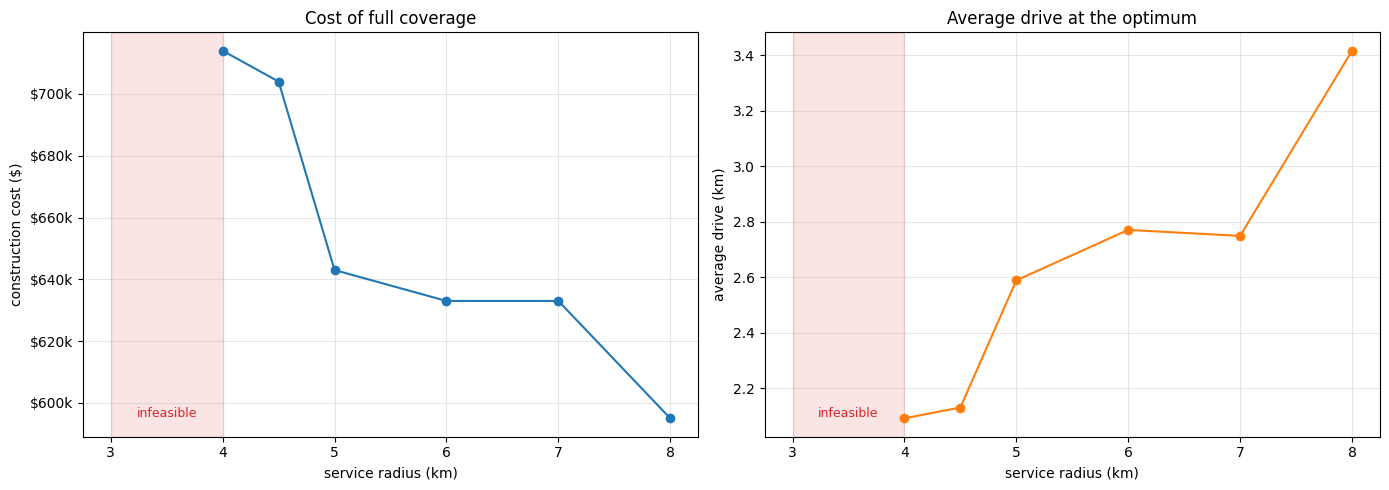

In [11]:
feas_radius = sweep_radius[sweep_radius['status'] == 'Optimal']
rmin = feas_radius['radius_km'].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_sweep(feas_radius, 'radius_km', 'cost', xlabel='service radius (km)',
           ylabel='construction cost ($)', title='Cost of full coverage', ax=axes[0])
plot_sweep(feas_radius, 'radius_km', 'avg_drive', xlabel='service radius (km)',
           ylabel='average drive (km)', title='Average drive at the optimum',
           ax=axes[1], color='tab:orange')
for ax in axes:
    ax.axvspan(min(radii), rmin, color='tab:red', alpha=0.12)
    ax.text((min(radii) + rmin) / 2, ax.get_ylim()[0] + 0.05 * np.ptp(ax.get_ylim()),
            'infeasible', color='tab:red', ha='center', fontsize=9)
axes[0].yaxis.set_major_formatter(lambda v, p: f'${v/1000:,.0f}k')
plt.tight_layout()
plt.savefig('../figures/radius_sweep.png', dpi=150)
plt.show()

**Findings.** Below 4 km the problem is infeasible at any budget, and it comes down to a
single demand point: D55, in the northeast corner, whose nearest candidate site is 3.51 km
away. Every other point has a site within 2.58 km. Infeasibility here is therefore a
statement about the candidate list, not about money — one extra candidate in that corner
would buy a 3 km standard.

From 4 km up the cost of full coverage falls steadily, \$714k at 4 km to \$595k at 8 km,
while the average drive rises 2.09 to 3.42 km. Tightening the standard from 5 km to 4 km
costs \$71k and loosening it from 5 km to 8 km saves \$48k — both small next to the \$643k
plan, so the radius is a cheap dial and the choice of 5 km is not doing much work in the
result. The build count never moves off 6, and S14, S16 and S18 appear at every feasible
radius.

## 2.4 Capacity sweep

Capacity is the assumption we are least sure about, so it gets a stress test.
`solve_model()` takes `capacity_scale`, so the data does not have to change.

In [12]:
scales = [0.5, 0.75, 1.0, 1.25, 1.5]
rows = []
for s in scales:
    r = solve(1_200_000, RADIUS, mode='min_cost', capacity_scale=s)
    rows.append({'capacity_scale': s, 'status': r['status'],
                 'n_built': len(r['built']), 'cost': r['total_cost']})
sweep_capacity = pd.DataFrame(rows)
sweep_capacity

,capacity_scale,status,n_built,cost
0,0.50,Infeasible,0,NaN
1,0.75,Optimal,8,910000.0
2,1.00,Optimal,6,643000.0
3,1.25,Optimal,5,548000.0
4,1.50,Optimal,4,450000.0


In [13]:
for s in [0.5, 0.6]:
    for B, tag in [(1_200_000, 'budget $1.2M'), (10_000_000, 'budget unlimited')]:
        r = solve(B, RADIUS, mode='min_cost', capacity_scale=s)
        cost = f"${r['total_cost']:,.0f}" if r['total_cost'] else '-'
        print(f'scale {s}, {tag:20s} -> {r["status"]:11s} '
              f'{len(r["built"]):2d} stations, {cost}')

print(f'\ntotal capacity at scale 0.5 = {sites["capacity"].sum() * 0.5:,.0f} '
      f'vs total demand {TOTAL_DEMAND:,}')

scale 0.5, budget $1.2M         -> Infeasible   0 stations, -
scale 0.5, budget unlimited     -> Optimal     13 stations, $1,527,000
scale 0.6, budget $1.2M         -> Infeasible   0 stations, -
scale 0.6, budget unlimited     -> Optimal     10 stations, $1,252,000

total capacity at scale 0.5 = 31,900 vs total demand 23,248


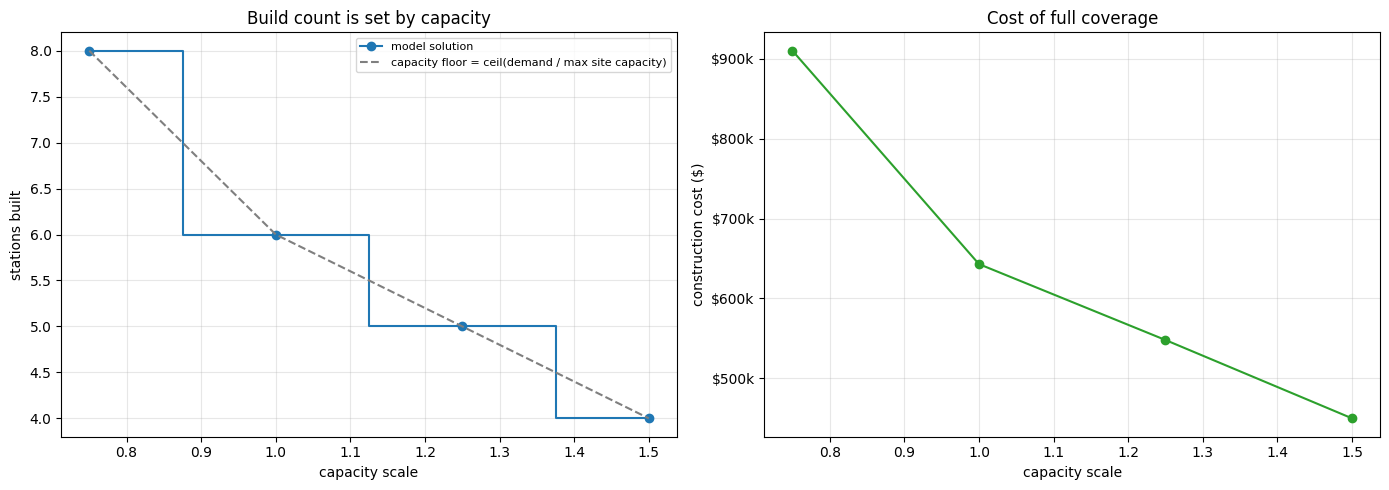

,capacity_scale,status,n_built,cost,capacity_floor
0,0.50,Infeasible,0,NaN,12
1,0.75,Optimal,8,910000.0,8
2,1.00,Optimal,6,643000.0,6
3,1.25,Optimal,5,548000.0,5
4,1.50,Optimal,4,450000.0,4


In [14]:
import math
max_cap = sites['capacity'].max()
sweep_capacity['capacity_floor'] = [math.ceil(TOTAL_DEMAND / (max_cap * s))
                                    for s in sweep_capacity['capacity_scale']]

feas_capacity = sweep_capacity[sweep_capacity['status'] == 'Optimal']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].step(feas_capacity['capacity_scale'], feas_capacity['n_built'], where='mid',
             marker='o', color='tab:blue', label='model solution')
axes[0].plot(feas_capacity['capacity_scale'], feas_capacity['capacity_floor'], '--',
             color='tab:gray', label='capacity floor = ceil(demand / max site capacity)')
axes[0].set_xlabel('capacity scale'); axes[0].set_ylabel('stations built')
axes[0].set_title('Build count is set by capacity')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(feas_capacity['capacity_scale'], feas_capacity['cost'], marker='o',
             color='tab:green')
axes[1].set_xlabel('capacity scale'); axes[1].set_ylabel('construction cost ($)')
axes[1].set_title('Cost of full coverage'); axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(lambda v, p: f'${v/1000:,.0f}k')
plt.tight_layout()
plt.savefig('../figures/capacity_sweep.png', dpi=150)
plt.show()

sweep_capacity

**Findings.** Capacity is the assumption the answer is most sensitive to. Halving it
takes the plan from 6 stations at \$643k to 13 stations at \$1.53M, a 2.4x cost swing
from one assumption; scaling it up by half takes it down to 4 stations at \$450k.

The `Infeasible` at scale 0.5 is a budget result, not a structural one. Total capacity at
that scale is 31,900 against 23,248 of demand, so full coverage is still possible — it
just costs \$1.53M, above the \$1.2M budget used here. Re-solving with an unlimited budget
is what separates the two, and it is worth doing before reporting any infeasibility.

The build count matches `ceil(total demand / largest site capacity)` exactly at every
feasible scale: 8, 6, 5, 4. So how many stations get built is arithmetic, set by
capacity; the optimisation is choosing *which* ones, which is where the cost and the
drive distance are won.

## 2.5 Maps

The strongest single figure is a starved budget next to the knee budget, since it makes
the trade-off visible in one image. Unserved demand points are circled in red.

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_657/1025338595.py:21: SyntaxWarning: invalid escape sequence '\$'
  title=(f'Budget \${B/1000:,.0f}k: {len(res["built"])} stations, '
/tmp/ipykernel_657/1025338595.py:22: SyntaxWarning: invalid escape sequence '\$'
  f'\${res["total_cost"]:,.0f}, {res["coverage_pct"]:.1f}% covered, '


$300,000: 3 stations, 51.6% covered, 19 of 56 points unserved
$650,000: 6 stations, 100.0% covered, 0 of 56 points unserved


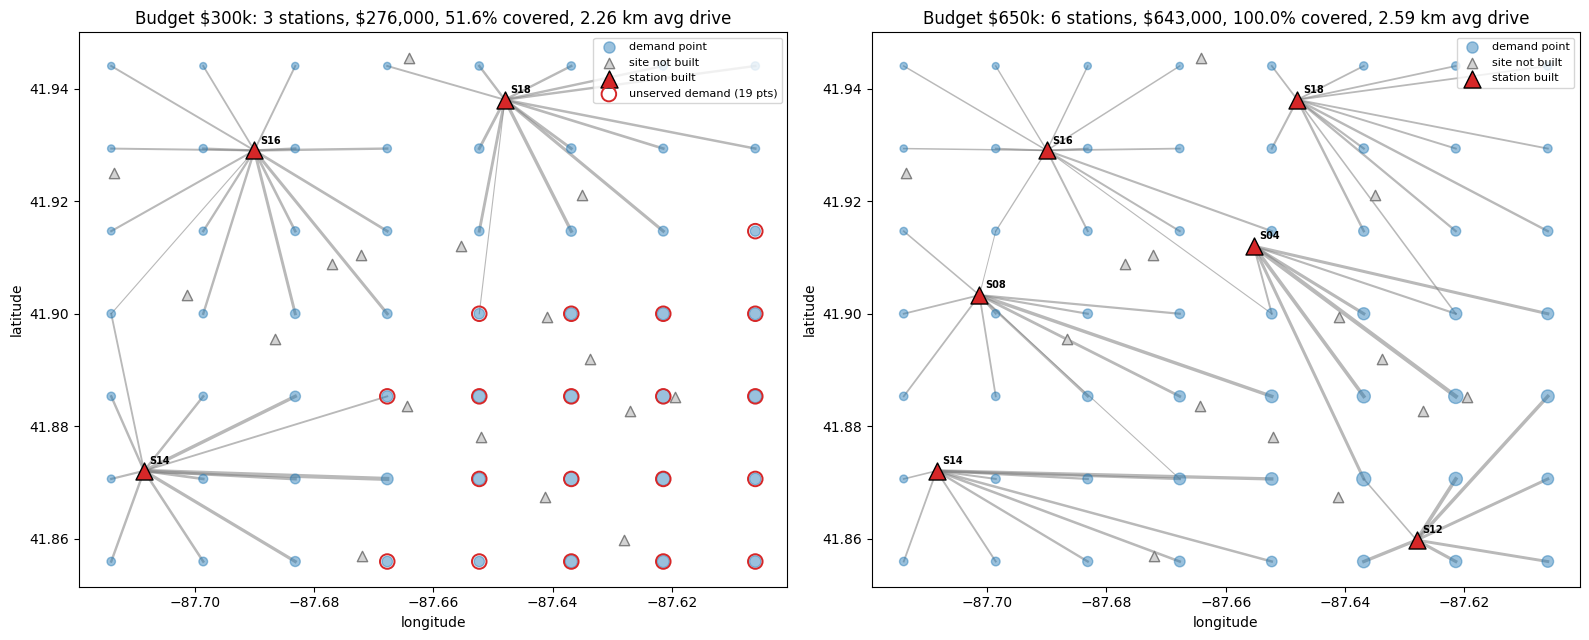

In [15]:
LOW, HIGH = 300_000, 650_000

def mark_uncovered(res, ax):
    """Circle the demand points that receive no service."""
    served = np.zeros(len(demands))
    for (i, j), v in res['assign'].items():
        served[i] += v
    unc = demands[served < 0.999]
    if len(unc):
        ax.scatter(unc.lon, unc.lat, s=110, facecolors='none', edgecolors='tab:red',
                   linewidths=1.4, zorder=5, label=f'unserved demand ({len(unc)} pts)')
    ax.legend(fontsize=8, loc='upper right')
    return len(unc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
low  = solve(LOW,  RADIUS, mode='max_coverage')
high = solve(HIGH, RADIUS, mode='max_coverage')

for res, B, ax in [(low, LOW, axes[0]), (high, HIGH, axes[1])]:
    plot_solution(res, sites, demands, ax=ax, annotate=True,
        title=(f'Budget \${B/1000:,.0f}k: {len(res["built"])} stations, '
               f'\${res["total_cost"]:,.0f}, {res["coverage_pct"]:.1f}% covered, '
               f'{res["avg_distance"]:.2f} km avg drive'))
    n = mark_uncovered(res, ax)
    print(f'${B:,}: {len(res["built"])} stations, {res["coverage_pct"]:.1f}% covered, '
          f'{n} of {len(demands)} points unserved')

plt.tight_layout()
plt.savefig('../figures/budget_comparison.png', dpi=150)
plt.show()

**Findings.** At \$300k the three affordable stations sit along the north and west edge
(S14, S16, S18) and 19 of 56 demand points receive nothing at all — the circled block is
the entire southeast quadrant, furthest from the cheap land the model is forced to buy.
At \$650k those three are still there, joined by S04, S08 and S12 filling in the south and
east; every point is served and the average drive is 2.59 km. The map makes the marginal
argument better than the table does: the extra \$367,000 of actual spend between the two
panels is what closes the whole southeast corner.

## 2.6 Decision support tool

`recommend(budget)` wraps the model so a planner can test scenarios without touching any
modelling code: give it a budget, get back a build list, a cost, a coverage number and a
map.

In [16]:
from IPython.display import display

def recommend(budget, radius=5.0, show_map=True):
    """Recommend a build plan for a given budget.

    Tries min_cost first: when full coverage is affordable that is what a planner wants,
    since it will not spend money on stations that add nothing. Falls back to
    max_coverage only when full coverage is unaffordable, which is exactly the case
    min_cost reports as Infeasible.
    """
    res = solve(budget, radius, mode='min_cost')
    mode = 'min_cost'
    if res['status'] != 'Optimal':
        res = solve(budget, radius, mode='max_coverage')
        mode = 'max_coverage'

    print(f'Recommended plan for a ${budget:,} budget at a {radius} km service radius')
    print('-' * 72)
    if res['status'] != 'Optimal':
        print(f'  No feasible plan ({res["status"]}). Below 4 km no budget works; '
              f'try a larger service radius.')
        return res

    if mode == 'min_cost':
        print('  Full coverage is affordable, so the plan minimises cost.')
    else:
        print('  Full coverage is NOT affordable here; the plan maximises demand served.')

    served = np.zeros(len(demands))
    for (i, j), v in res['assign'].items():
        served[i] += v
    n_unserved = int((served < 0.999).sum())

    print(f'  stations to build : {len(res["built"])} -> '
          f'{list(sites.site_id.iloc[res["built"]])}')
    print(f'  construction cost : ${res["total_cost"]:,.0f}')
    print(f'  budget unused     : ${budget - res["total_cost"]:,.0f}')
    print(f'  demand covered    : {res["coverage_pct"]:.1f}%')
    print(f'  points unserved   : {n_unserved} of {len(demands)}')
    print(f'  average drive     : {res["avg_distance"]:.2f} km')

    display(sites.iloc[res['built']][['site_id', 'amenity', 'lon', 'lat',
                                      'cost', 'capacity']])

    if show_map:
        plot_solution(res, sites, demands, annotate=True,
            title=(f'Recommended plan, \${budget/1000:,.0f}k budget '
                   f'({len(res["built"])} stations, {res["coverage_pct"]:.0f}% covered)'))
        plt.tight_layout(); plt.show()
    return res

<>:47: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_657/2256545652.py:47: SyntaxWarning: invalid escape sequence '\$'
  title=(f'Recommended plan, \${budget/1000:,.0f}k budget '


Recommended plan for a $300,000 budget at a 5.0 km service radius
------------------------------------------------------------------------
  Full coverage is NOT affordable here; the plan maximises demand served.
  stations to build : 3 -> ['S14', 'S16', 'S18']
  construction cost : $276,000
  budget unused     : $24,000
  demand covered    : 51.6%
  points unserved   : 19 of 56
  average drive     : 2.26 km


,site_id,amenity,lon,lat,cost,capacity
14,S14,parking,-87.7085,41.8721,95000,4000
16,S16,parking,-87.6900,41.9290,88000,4000
18,S18,parking,-87.6480,41.9380,93000,4000


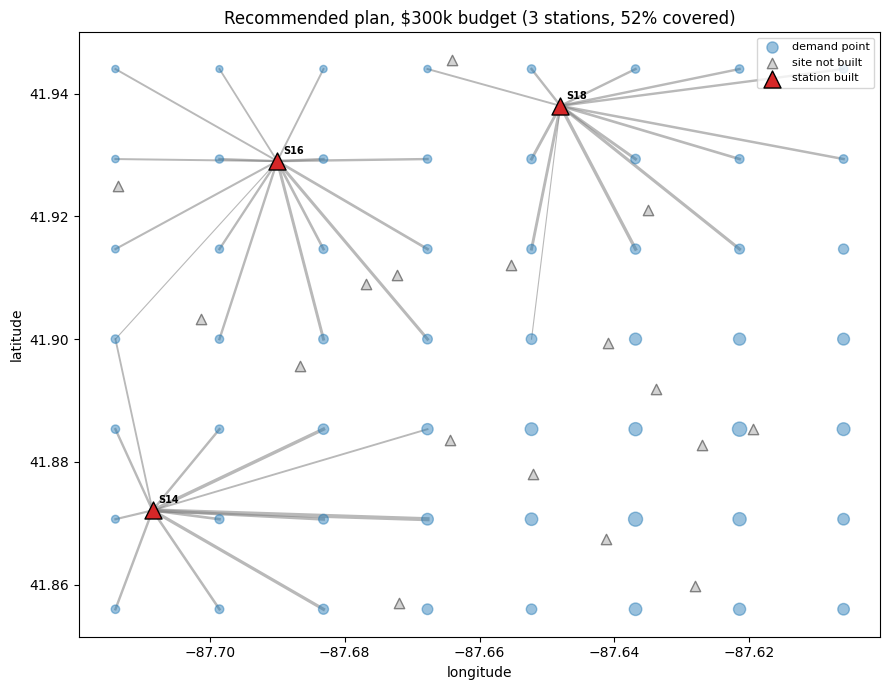

Recommended plan for a $650,000 budget at a 5.0 km service radius
------------------------------------------------------------------------
  Full coverage is affordable, so the plan minimises cost.
  stations to build : 6 -> ['S04', 'S08', 'S12', 'S14', 'S16', 'S18']
  construction cost : $643,000
  budget unused     : $7,000
  demand covered    : 100.0%
  points unserved   : 0 of 56
  average drive     : 2.59 km


,site_id,amenity,lon,lat,cost,capacity
4,S04,parking,-87.6553,41.9120,117000,4000
8,S08,parking,-87.7013,41.9033,95000,4000
12,S12,parking,-87.6280,41.8598,155000,4000
14,S14,parking,-87.7085,41.8721,95000,4000
16,S16,parking,-87.6900,41.9290,88000,4000
18,S18,parking,-87.6480,41.9380,93000,4000


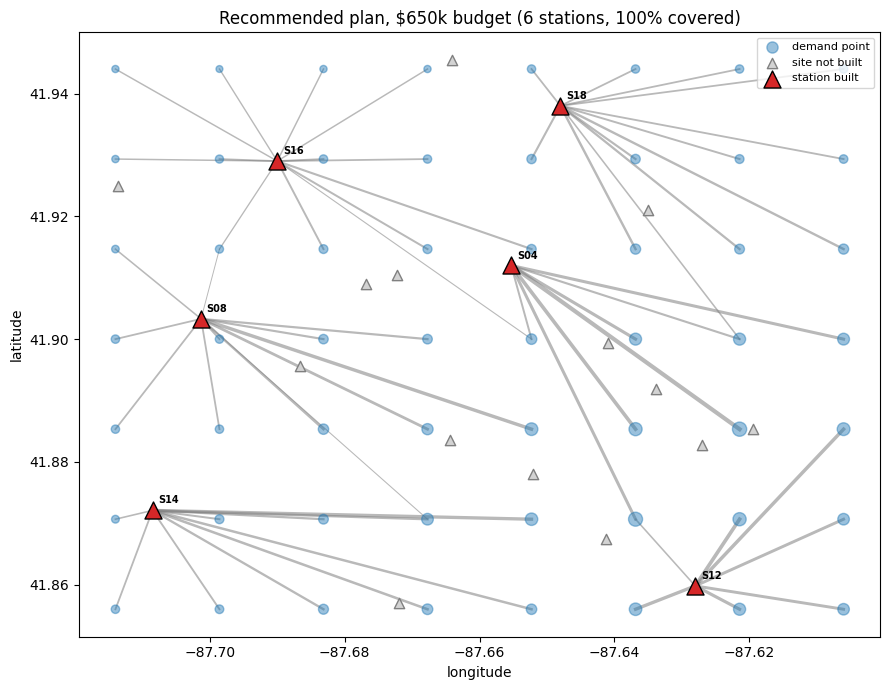

Recommended plan for a $900,000 budget at a 5.0 km service radius
------------------------------------------------------------------------
  Full coverage is affordable, so the plan minimises cost.
  stations to build : 6 -> ['S04', 'S08', 'S12', 'S14', 'S16', 'S18']
  construction cost : $643,000
  budget unused     : $257,000
  demand covered    : 100.0%
  points unserved   : 0 of 56
  average drive     : 2.59 km


,site_id,amenity,lon,lat,cost,capacity
4,S04,parking,-87.6553,41.9120,117000,4000
8,S08,parking,-87.7013,41.9033,95000,4000
12,S12,parking,-87.6280,41.8598,155000,4000
14,S14,parking,-87.7085,41.8721,95000,4000
16,S16,parking,-87.6900,41.9290,88000,4000
18,S18,parking,-87.6480,41.9380,93000,4000


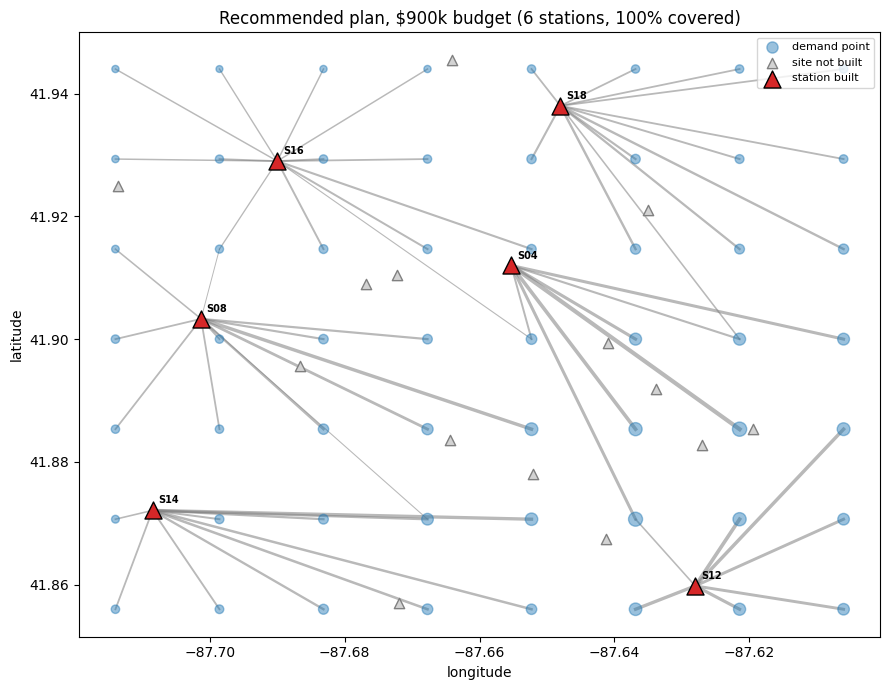

In [17]:
_ = recommend(300_000)   # starved: below the knee
_ = recommend(650_000)   # at the knee
_ = recommend(900_000)   # surplus: above the knee

**Findings.** The three demos cover the three regimes a planner actually faces. At \$300k
the tool reports honestly that full coverage is unaffordable and returns the best
partial plan, 51.6 percent with 19 points unserved. At \$650k it switches to `min_cost`,
spends \$643k and covers everyone. At \$900k it returns *the same six stations* and
reports \$257,000 of budget unused — the useful answer being that the extra money should
go somewhere other than more stations. Automatic fallback between the two modes is what
lets one function answer all three without the planner having to know which formulation
applies.

## 2.7 Conclusions

In [18]:
from collections import Counter

freq, n_scen = Counter(), 0
for b in budgets:                                   # budget sweep, max_coverage
    r = solve(b, RADIUS, mode='max_coverage')
    if r['status'] == 'Optimal':
        n_scen += 1; freq.update(sites.site_id.iloc[r['built']])
for R in radii:                                     # radius sweep, min_cost
    r = solve(1_200_000, radius=R, mode='min_cost')
    if r['status'] == 'Optimal':
        n_scen += 1; freq.update(sites.site_id.iloc[r['built']])
for s in scales:                                    # capacity sweep, min_cost
    r = solve(1_200_000, RADIUS, mode='min_cost', capacity_scale=s)
    if r['status'] == 'Optimal':
        n_scen += 1; freq.update(sites.site_id.iloc[r['built']])

robust = (pd.DataFrame({'site_id': list(freq), 'times_chosen': list(freq.values())})
          .merge(sites[['site_id', 'amenity', 'cost', 'capacity']], on='site_id')
          .assign(pct_of_scenarios=lambda d: (100 * d.times_chosen / n_scen).round(0),
                  cost_per_capacity=lambda d: (d.cost / d.capacity).round(1))
          .sort_values('times_chosen', ascending=False)
          .reset_index(drop=True))
print(f'{n_scen} scenarios across the three sweeps')
robust.head(10)

28 scenarios across the three sweeps


,site_id,times_chosen,amenity,cost,capacity,pct_of_scenarios,cost_per_capacity
0,S14,25,parking,95000,4000,89.0,23.8
1,S16,22,parking,88000,4000,79.0,22.0
2,S18,21,parking,93000,4000,75.0,23.2
3,S12,17,parking,155000,4000,61.0,38.8
4,S04,16,parking,117000,4000,57.0,29.2
5,S08,12,parking,95000,4000,43.0,23.8
6,S06,12,parking,107000,4000,43.0,26.8
7,S17,9,fuel,85000,2200,32.0,38.6
8,S02,5,parking,166000,4000,18.0,41.5
9,S07,3,fuel,108000,2200,11.0,49.1


**Where the knee is, and what it means.** Coverage rises steadily to \$643,000 and is
flat above it. \$643,000 buys six stations — S04, S08, S12, S14, S16, S18 — and serves
100 percent of demand with a 2.59 km average drive; a seventh station becomes affordable
at \$750k and adds nothing. For a planner the recommendation is to fund \$643k, and to treat
anything above it as money that belongs in chargers per site, maintenance, or a larger
study area rather than in more locations. Below the knee the loss is steep and specific:
the \$488k plan, 76 percent of the knee cost, covers 84 percent of demand, and at \$300k,
19 of 56 demand points get nothing at all.

**Which sites are robust.** S14 (Lawndale), S16 (Logan Square) and S18 (Lakeview) are the
robust core: they are chosen in 89, 79 and 75 percent of the 28 scenarios across the three
sweeps, and in every feasible service radius from 4 to 8 km. They are also among the
cheapest sources of capacity in the candidate list — \$22.0, \$23.2 and \$23.8 of
construction cost per unit of capacity (S14 tied with S08) against a median of \$40.75 —
which is *why* they are robust
rather than lucky: the model is capacity-constrained, so cost per unit of capacity is what
decides, and the 4,000-capacity garages dominate the 2,200-capacity fuel stations on that
ratio. No fuel site is chosen in even a third of the scenarios.

The other three sites in the \$643k plan — S04, S08 and S12 — are weaker picks and the
report should say so. Each completes the plan under the base assumptions, but they trade
places as the radius moves: S02 replaces S08 at 4 km, S06 replaces S04 at 6 and 7 km, and
S12 drops out entirely at 8 km. Across all 28 scenarios S06 is chosen exactly as often as
S08. So the recommendation is to commit to S14, S16 and S18 as phase 1 and to
treat the remaining three slots as a decision to revisit once the capacity and radius
assumptions are firmer.

**Which assumption is riskiest.** Capacity, by a wide margin. Halving it moves the plan
from 6 stations at \$643k to 13 at \$1.53M; the radius, by contrast, moves the answer by
tens of thousands of dollars per kilometre over 4–8 km. The build count matches
`ceil(total demand / largest site capacity)` at every feasible scale from 0.75 to 1.5, so
the number of stations is set almost entirely by that one number. It is also
the assumption with the weakest evidence behind it: 4,000 vehicles per day per garage is
a stand-in, not a measurement. Anyone extending this should price capacity first, and
should treat the model's real contribution as *which* sites to pick rather than *how
many* — the count is arithmetic, the selection is optimisation.

**What we would add with more time.** Road network distances from OSM instead of great
circle, since straight lines understate real driving distance in a street grid and
therefore overstate coverage at a given radius. Existing public chargers as pre-built
sites with `y_j` fixed to 1, which is what makes the output a marginal investment plan
rather than a greenfield one. Demand growth over a multi-year horizon with staged
construction, so the six robust sites become a phase 1 and the rest a phase 2. And
charger count per station as a decision variable instead of fixed capacity, which is the
change that would matter most given that capacity is what the answer turns on. A sweep on
the construction cost assumption is also missing here — we varied budget, radius and
capacity but never the cost curve itself, so its influence is asserted rather than shown.